In [1]:

import sys
sys.path.append('/Users/owenmeyer/dsp-modeler/black_box/train')
print(sys.path)

['/home/ubuntu/dsp-modeler', '/home/ubuntu/dsp-modeler/black_box/train', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/home/ubuntu/dsp-modeler/.venv/lib/python3.12/site-packages', '/Users/owenmeyer/dsp-modeler/black_box/train']


In [2]:
import torch, os
import numpy as np
from data_objects import DataSet

In [2]:
param_names=["d", "f", "v"]
param_configs={
    'd':{'min':1, 'max':7, 'dtype':torch.float32},
    'f':{'min':1, 'max':7, 'dtype':torch.float32},
    'v':{'min':1, 'max':7, 'dtype':torch.float32},
}

# DATA VIZ

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_gain_grids(data, const_vals=(1, 3, 5, 7), grid_range=range(1, 8), save_path=None):
    """
    data: list of [param_1_val, param_2_val, param_3_val, gain_val] rows.
    Row 0: param_1_val held constant per column -> axes (param_2_val, param_3_val)
    Row 1: param_2_val held constant per column -> axes (param_1_val, param_3_val)
    Row 2: param_3_val held constant per column -> axes (param_1_val, param_2_val)
    save_path: if given, saves the figure to this path (e.g. 'gain_grids.png').
    """
    grid_range = list(grid_range)
    n = len(grid_range)
    idx = {v: i for i, v in enumerate(grid_range)}
    param_names = ['Dist', 'Freq', 'Vol']

    row_configs = [
        (0, 1, 2),
        (1, 0, 2),
        (2, 0, 1),
    ]

    fig, axes = plt.subplots(3, len(const_vals), figsize=(5 * len(const_vals), 15))

    for row, (const_idx, row_idx, col_idx) in enumerate(row_configs):
        for col, const_v in enumerate(const_vals):
            ax = axes[row, col]
            grid = np.full((n, n), np.nan)
            for r in data:
                params, gain = r[:3], r[3]
                if params[const_idx] != const_v:
                    continue
                rv, cv = params[row_idx], params[col_idx]
                if rv in idx and cv in idx:
                    grid[idx[rv], idx[cv]] = gain

            im = ax.imshow(grid, cmap='viridis', origin='lower')
            ax.set_xticks(range(n)); ax.set_xticklabels(grid_range)
            ax.set_yticks(range(n)); ax.set_yticklabels(grid_range)
            ax.set_xlabel(param_names[col_idx])
            ax.set_ylabel(param_names[row_idx])
            ax.set_title(f'{param_names[const_idx]} = {const_v}')

            for i in range(n):
                for j in range(n):
                    val = grid[i, j]
                    if not np.isnan(val):
                        norm_val = im.norm(val)
                        text_color = 'black' if norm_val > 0.5 else 'white'
                        ax.text(j, i, f'{val:.3g}', ha='center', va='center',
                                color=text_color, fontsize=8)

            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=130, bbox_inches='tight')
    plt.show()

In [ ]:
train_dataset = DataSet(
    '/home/ubuntu/dsp-modeler/data/outputs/manifest.jsonl', 
    '/home/ubuntu/dsp-modeler/data/input/input.wav', 
    '/home/ubuntu/dsp-modeler/data/outputs', 
    0.03, 
    ["d", "f", "v"], 
    {'d':{'min':1, 'max':7, 'dtype':torch.float32},'f':{'min':1, 'max':7, 'dtype':torch.float32},'v':{'min':1, 'max':7, 'dtype':torch.float32}}, 
    silent_lead_in_seconds=8, 
    trim_noise = True
)

For /home/ubuntu/dsp-modeler/data/outputs/a4c49ad9-6ff5-4287-80a1-0d7ae2028d70.wav

+12608 samples (+131.328 ms)
12607
n_samples 23411393 w n_chunks 8128
For /home/ubuntu/dsp-modeler/data/outputs/95acc994-d2f5-40a8-8ea1-fe873eccf4a5.wav

+12606 samples (+131.307 ms)
12605
n_samples 23411395 w n_chunks 8128
For /home/ubuntu/dsp-modeler/data/outputs/2a8704b9-0e6d-46f1-a910-96df3e7f3c12.wav

-25462 samples (-265.229 ms)
-25462
n_samples 23398538 w n_chunks 8124
For /home/ubuntu/dsp-modeler/data/outputs/8306953c-daff-40e5-a363-2c648ead8437.wav

+62712 samples (+653.250 ms)
62712
n_samples 23361288 w n_chunks 8111
For /home/ubuntu/dsp-modeler/data/outputs/a8747186-e3ce-4327-b144-0346bcea7550.wav

-19040 samples (-198.333 ms)
-19040
n_samples 23404960 w n_chunks 8126
For /home/ubuntu/dsp-modeler/data/outputs/b150a563-244f-499e-9957-9af49a7d3595.wav

-77842 samples (-810.854 ms)
-77842
n_samples 23346158 w n_chunks 8106
For /home/ubuntu/dsp-modeler/data/outputs/fbed9477-c92a-4901-99f3-111417f

In [16]:
rows = []
for track in train_dataset:
    row=[]
    params = track[0][0].params
    for p in param_names:
        row.append(params[p])

    gain = track.compute_wet_gain()
    row.append(float(gain))
    
    # noise_profile = track[0].noise_profile
    # row.append[noise_profile[0][0]]


    rows.append(row)

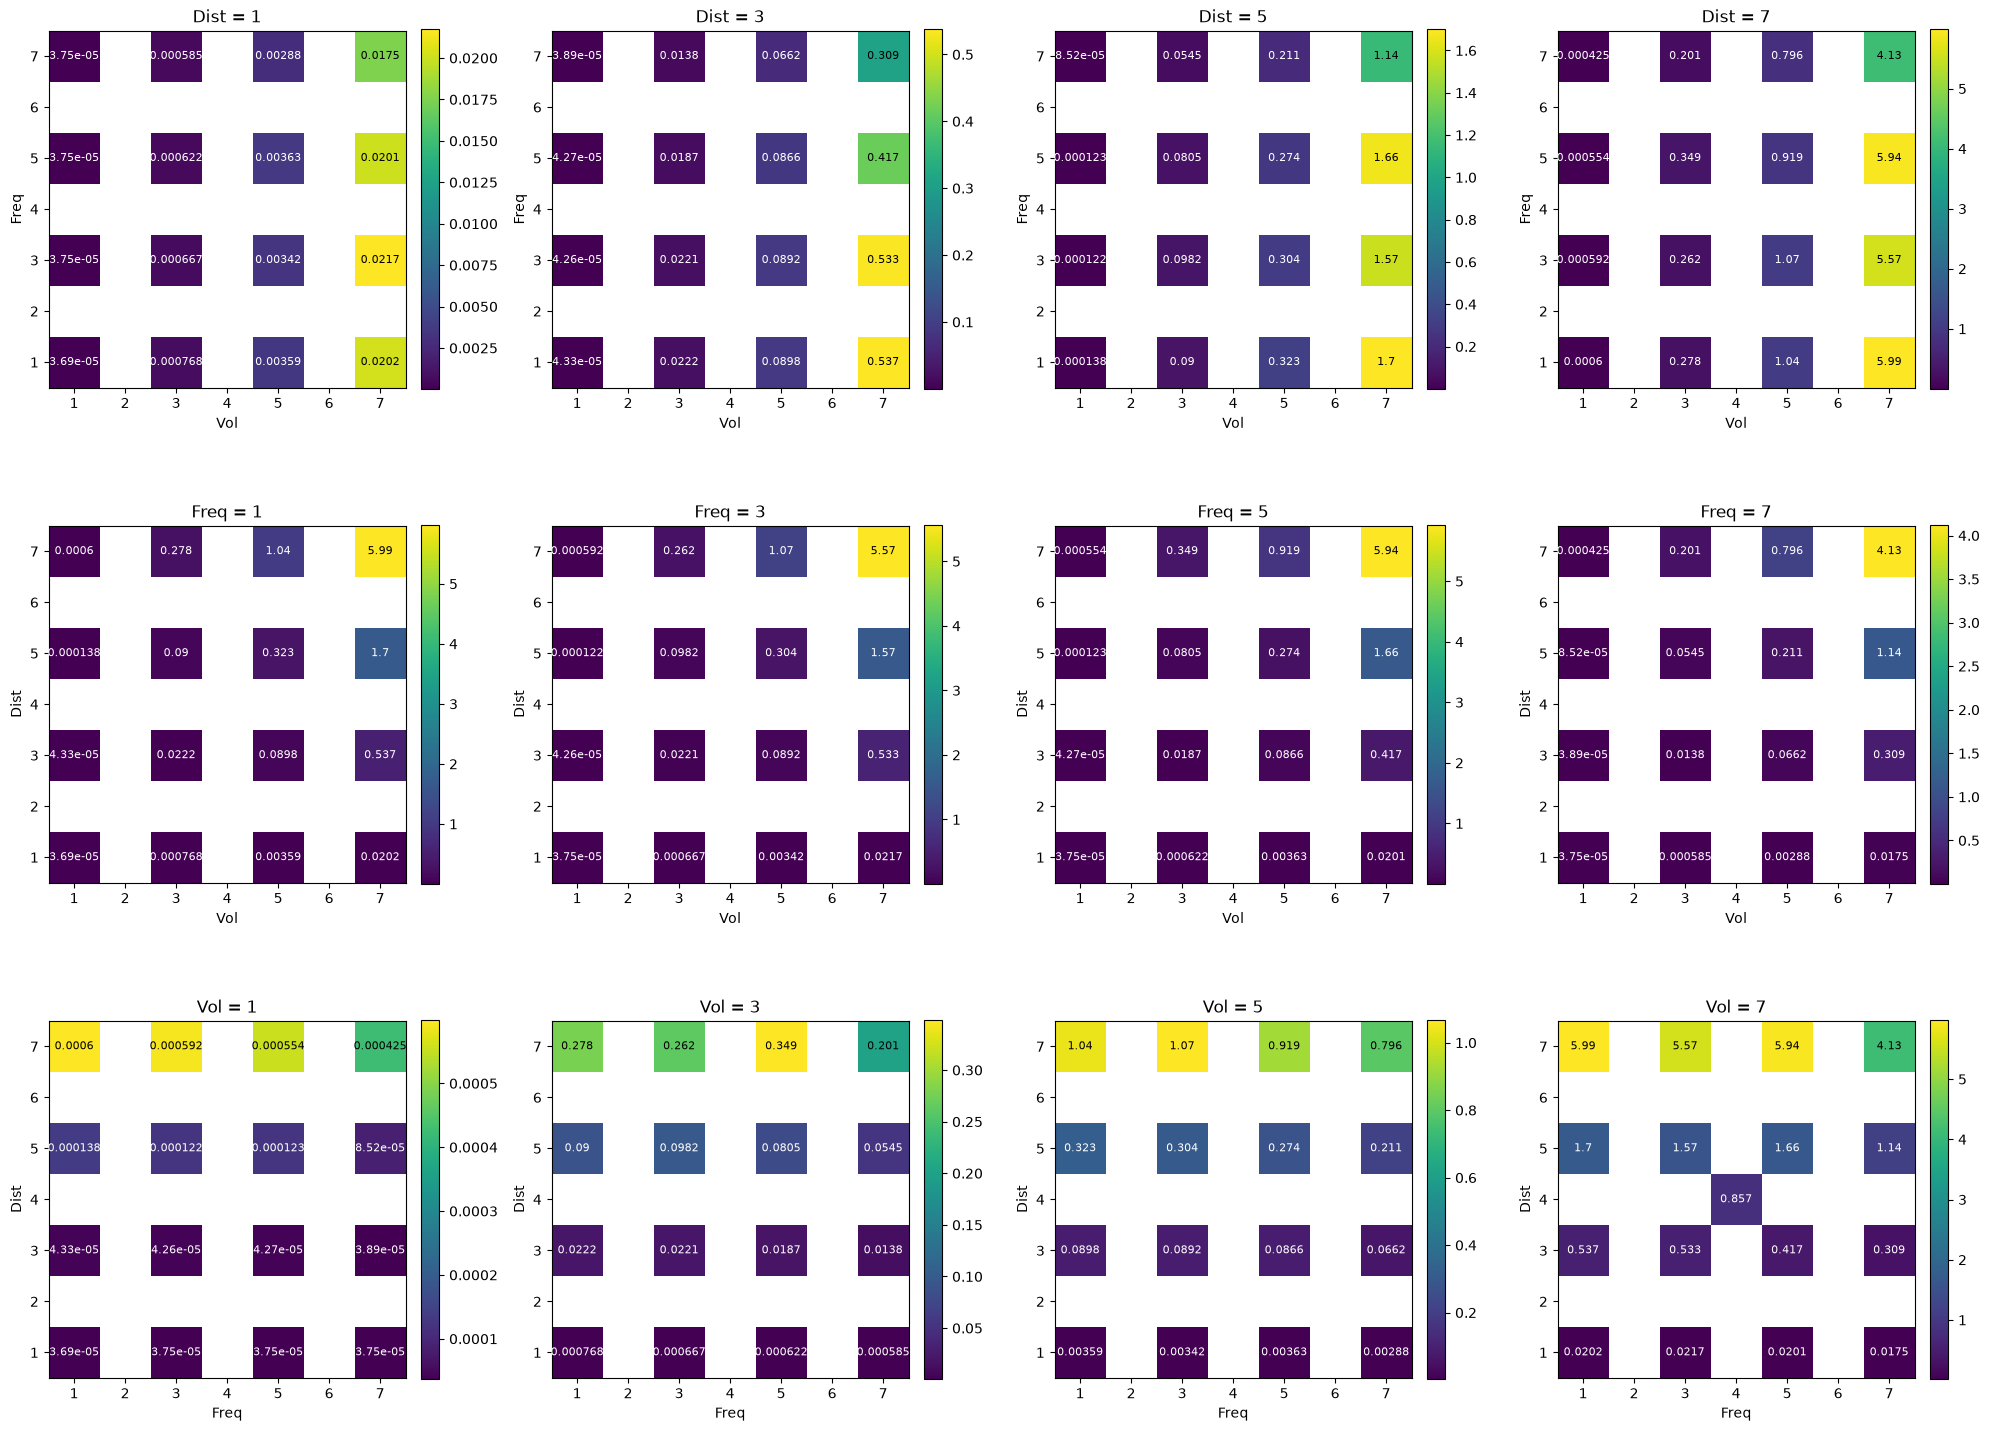

In [ ]:
plot_gain_grids(rows, const_vals=(1, 3, 5, 7), grid_range=range(1, 8), save_path='/home/ubuntu/dsp-modeler/black_box/train/viz/params.png')

In [3]:
train_dataset_2 = DataSet(
    '/home/ubuntu/dsp-modeler/data/outputs/manifest.jsonl', 
    '/home/ubuntu/dsp-modeler/data/input/input.wav', 
    '/home/ubuntu/dsp-modeler/data/outputs', 
    0.03, 
    ["d", "f", "v"], 
    {'d':{'min':1, 'max':7, 'dtype':torch.float32},'f':{'min':1, 'max':7, 'dtype':torch.float32},'v':{'min':1, 'max':7, 'dtype':torch.float32}}, 
    silent_lead_in_seconds=8, 
    trim_noise = False
)

For /home/ubuntu/dsp-modeler/data/outputs/a4c49ad9-6ff5-4287-80a1-0d7ae2028d70.wav

+12608 samples (+131.333 ms)
12608
n_samples 23411392 w n_chunks 8128
For /home/ubuntu/dsp-modeler/data/outputs/95acc994-d2f5-40a8-8ea1-fe873eccf4a5.wav

+12606 samples (+131.312 ms)
12606
n_samples 23411394 w n_chunks 8128
For /home/ubuntu/dsp-modeler/data/outputs/2a8704b9-0e6d-46f1-a910-96df3e7f3c12.wav

+35139 samples (+366.031 ms)
35139
n_samples 23388861 w n_chunks 8121
For /home/ubuntu/dsp-modeler/data/outputs/8306953c-daff-40e5-a363-2c648ead8437.wav

+54098 samples (+563.516 ms)
54097
n_samples 23369903 w n_chunks 8114
For /home/ubuntu/dsp-modeler/data/outputs/a8747186-e3ce-4327-b144-0346bcea7550.wav

-75050 samples (-781.766 ms)
-75049
n_samples 23348951 w n_chunks 8107
For /home/ubuntu/dsp-modeler/data/outputs/b150a563-244f-499e-9957-9af49a7d3595.wav

+64343 samples (+670.240 ms)
64343
n_samples 23359657 w n_chunks 8110
For /home/ubuntu/dsp-modeler/data/outputs/fbed9477-c92a-4901-99f3-111417fc4

In [ ]:
rows2 = []
for track in train_dataset_2:
    row=[]
    params = track[0][0].params
    for p in param_names:
        row.append(params[p])

    gain = track.compute_wet_gain()
    row.append(float(gain))
    
    # noise_profile = track[0].noise_profile
    # row.append[noise_profile[0][0]]


    rows.append(row2)

{'d': 4.0, 'f': 4.0, 'v': 6.0}
{'d': 4.0, 'f': 4.0, 'v': 6.0}
{'d': 4.0, 'f': 4.0, 'v': 6.0}
{'d': 4.0, 'f': 4.0, 'v': 7.0}
{'d': 4.0, 'f': 4.0, 'v': 7.0}
{'d': 4.0, 'f': 4.0, 'v': 7.0}
{'d': 1.0, 'f': 1.0, 'v': 1.0}
{'d': 1.0, 'f': 1.0, 'v': 1.0}
{'d': 1.0, 'f': 1.0, 'v': 1.0}
{'d': 1.0, 'f': 3.0, 'v': 1.0}
{'d': 1.0, 'f': 3.0, 'v': 1.0}
{'d': 1.0, 'f': 3.0, 'v': 1.0}
{'d': 1.0, 'f': 5.0, 'v': 1.0}
{'d': 1.0, 'f': 5.0, 'v': 1.0}
{'d': 1.0, 'f': 5.0, 'v': 1.0}
{'d': 1.0, 'f': 7.0, 'v': 1.0}
{'d': 1.0, 'f': 7.0, 'v': 1.0}
{'d': 1.0, 'f': 7.0, 'v': 1.0}
{'d': 1.0, 'f': 1.0, 'v': 3.0}
{'d': 1.0, 'f': 1.0, 'v': 3.0}
{'d': 1.0, 'f': 1.0, 'v': 3.0}
{'d': 1.0, 'f': 1.0, 'v': 5.0}
{'d': 1.0, 'f': 1.0, 'v': 5.0}
{'d': 1.0, 'f': 1.0, 'v': 5.0}
{'d': 1.0, 'f': 1.0, 'v': 7.0}
{'d': 1.0, 'f': 1.0, 'v': 7.0}
{'d': 1.0, 'f': 1.0, 'v': 7.0}
{'d': 1.0, 'f': 3.0, 'v': 3.0}
{'d': 1.0, 'f': 3.0, 'v': 3.0}
{'d': 1.0, 'f': 3.0, 'v': 3.0}
{'d': 1.0, 'f': 3.0, 'v': 5.0}
{'d': 1.0, 'f': 3.0, 'v': 5.0}
{'d': 1.

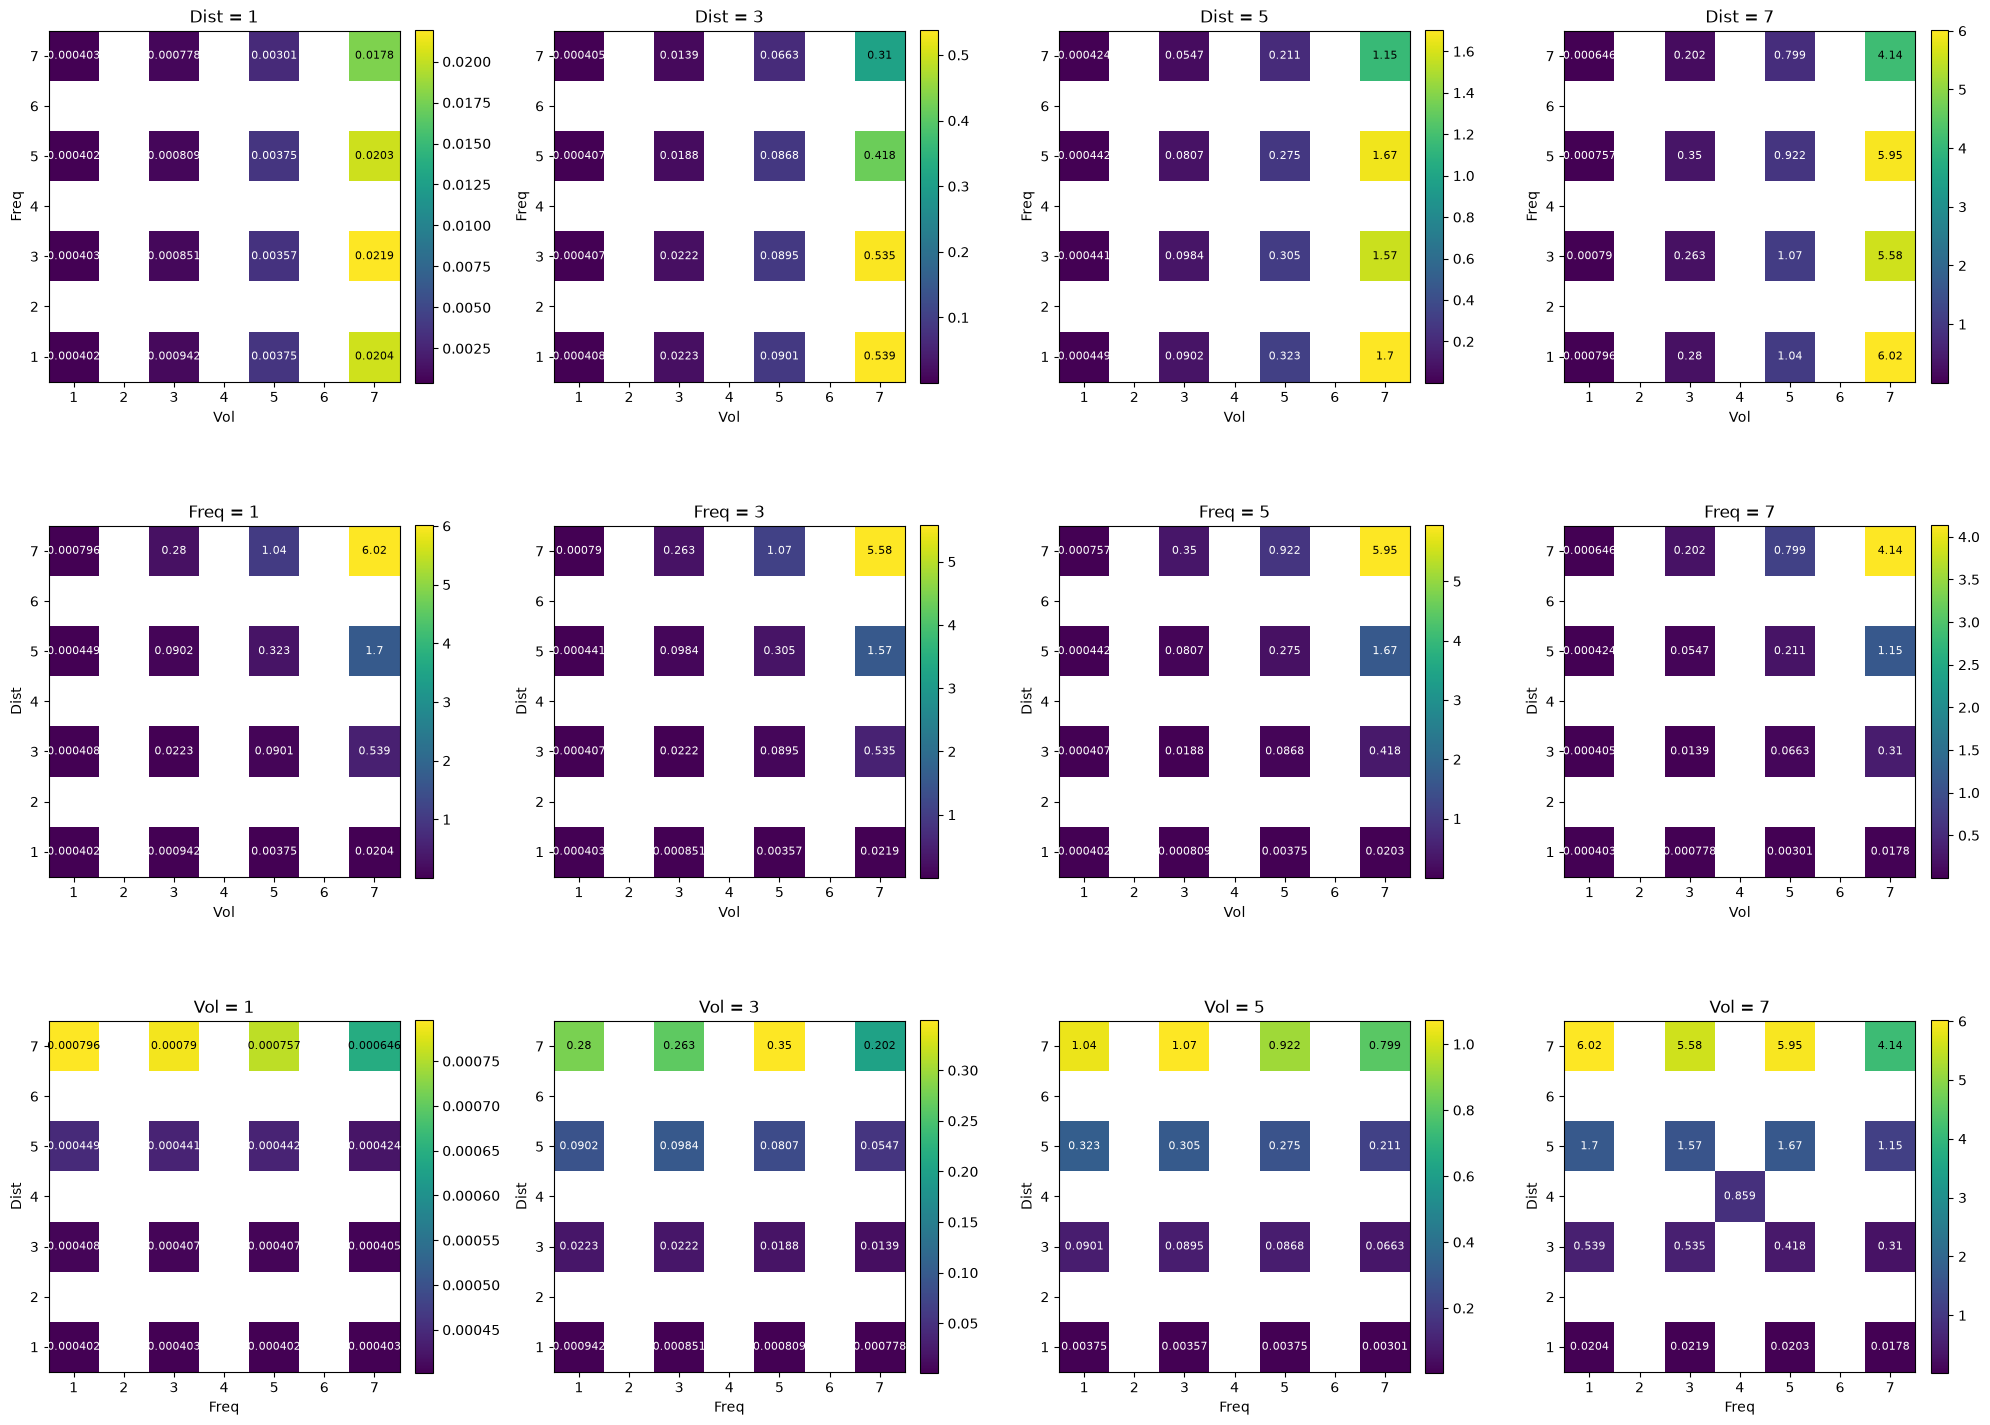

In [ ]:
plot_gain_grids(rows2, const_vals=(1, 3, 5, 7), grid_range=range(1, 8), save_path='/home/ubuntu/dsp-modeler/black_box/train/viz/params_dn.png')

# TRAIN GAIN PROFILER

In [3]:
import torch, os
import numpy as np
from data_objects import DataSet
from model_objects import GainModel
param_names=["d", "f", "v"]
param_configs={
    'd':{'min':1, 'max':7, 'dtype':torch.float32},
    'f':{'min':1, 'max':7, 'dtype':torch.float32},
    'v':{'min':1, 'max':7, 'dtype':torch.float32},
}
chunk_seconds=0.03
trim_noise=True
silent_lead_in_seconds=8
device='cuda'

In [4]:
gain_model = GainModel(param_configs)
gain_model.load('/home/ubuntu/dsp-modeler/black_box/model/models/gain_model/2026-08-18_20-17/gain_model.npz')

In [5]:
example_dataset = DataSet(
    '/home/ubuntu/dsp-modeler/black_box/data/train_single/manifest.jsonl', 
    '/home/ubuntu/dsp-modeler/data/input/input.wav', 
    '/home/ubuntu/dsp-modeler/data/outputs', 
    chunk_seconds, 
    param_names, 
    param_configs, 
    silent_lead_in_seconds=silent_lead_in_seconds, 
    trim_noise = trim_noise
)

loading dataset
Load dry: /home/ubuntu/dsp-modeler/data/input/input.wav
chunk_len 2880
segment_size 20
Load wet (0/1): /home/ubuntu/dsp-modeler/data/outputs/1f9fd0a8-1608-41b4-b7e5-2c697b39a4f1.wav
# Chunks 8120
# Segments 406
# Tracks 1
# min_segments 405


In [6]:
example_dataset.apply_gain_model(gain_model)

In [8]:
[len(b) for b in example_dataset.batches_of_random()]

[30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 15]

In [ ]:
train_dataset=example_dataset

for i, batch in enumerate(train_dataset.batches_of_random()):
    if i !=0: break
    print(f"b:{i}")

    #print(batch.get_gains(device, param_names))

    seg = batch[0]
    chunk = seg[0]

    # print(f"normalize_params {chunk.normalize_params(param_configs)}")
    # print(f"get_param_tensors {chunk.get_param_tensors(device, param_names, param_configs)}")
    # print(f"get_dry_tensor {chunk.get_dry_tensor(device)}")
    # print(f"get_wet_tensor {chunk.get_wet_tensor(device) }")
    # print(f"get_target_tensor {chunk.get_target_tensor(device)}")
    #print(f"get_features_tensor {chunk.get_features_tensor(device, param_names, param_configs)}")

    # print(f"get_features_tensor {seg.get_features_tensor(device, param_names, param_configs)}")
    # print(f"get_target_tensor {seg.get_target_tensor(device)}")

    # print(f"get_features_tensor {batch.get_features_tensor(device, param_names, param_configs)}")
    # print(f"get_target_tensor {batch.get_target_tensor(device)}")
    # print(f"get_gains_tensor {batch.get_gains_tensor(device, param_names)}")


    chunk_features = []
    # for chunk in seg:
    #     #chunk = seg[0]

    #     # get_dry_tensor
    #     dry_tensor = torch.from_numpy(chunk.dry_data).to(device)
    #     # print(f"dry_tensor {dry_tensor}")

    #     # get_param_tensors
    #     norm_params = chunk.normalize_params(param_configs)
    #     param_tensors = [torch.tensor([norm_params[pn]], dtype=param_configs[pn]['dtype'], device=device) for pn in param_names]
    #     # print(f"param_tensors {param_tensors}")

    #     # params to dry length
    #     expanded_params = [param_tensor.repeat(len(dry_tensor)) for param_tensor in param_tensors]
    #     # print(f"expanded_params {expanded_params}")

    #     # combine param columns
    #     features_tensors=[dry_tensor]+expanded_params
    #     #print(f"features_tensors {features_tensors}")

    #     # transpose to time-space
    #     transposed_tensor = torch.stack(features_tensors).T
    #     #print(f"transposed_tensor {transposed_tensor}")
    #     chunk_features.append(transposed_tensor)

    #     # features_tensor_2 = chunk.get_features_tensor(device, param_names, param_configs)
    #     # print(f"features_tensor_2 {features_tensor_2}")
    # segment_features = torch.cat(chunk_features, dim=0)
    # print(f"segment_features {segment_features}")

    
    # print(f"get_features_tensors {seg.get_features_tensors(device, param_names, param_configs)}")




b:0
wet_gain_tensor tensor([0.0135, 0.0135, 0.0135, 0.0135, 0.0135, 0.0135, 0.0135, 0.0135, 0.0135,
        0.0135, 0.0135, 0.0135, 0.0135, 0.0135, 0.0135, 0.0135, 0.0135, 0.0135,
        0.0135, 0.0135, 0.0135, 0.0135, 0.0135, 0.0135, 0.0135, 0.0135, 0.0135,
        0.0135, 0.0135, 0.0135], device='cuda:0')
param_gain_tensor [tensor([1.], device='cuda:0'), tensor([1.], device='cuda:0'), tensor([1.], device='cuda:0')]
expanded_param_gains [tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0'), tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0'), tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0')]
gains_tensors [tensor([0.0135, 0.0135, 0.0135, 0.0135, 0.0135, 0.0135, 0.0135, 0.0135, 0.01

In [ ]:

features_tensors[0]
features_tensors[0][]

tensor([[ 0.0632, -0.3333, -0.3333, -0.3333],
        [ 0.0642, -0.3333, -0.3333, -0.3333],
        [ 0.0651, -0.3333, -0.3333, -0.3333],
        ...,
        [-0.0051, -0.3333, -0.3333, -0.3333],
        [-0.0050, -0.3333, -0.3333, -0.3333],
        [-0.0047, -0.3333, -0.3333, -0.3333]], device='cuda:0')